# Component 1 — Classical Data Generation
### AI Design of Quantum Processors · Mondragon-Shem Quantum Group (UIC)
**Author:** Marcos Sandoval Lucas

**Goal of this component.** Simulate the classical harmonic oscillator (a mass on a spring) and generate the *classical baseline data* — energy structure and phase-space trajectories — that will later become **inputs** to the machine-learning model in Component 3.

**What you will do here**
- **Task 1:** state the energy function, derive the equations of motion, and map the energy in phase space.
- **Task 2:** numerically integrate the motion and plot trajectories for many starting conditions.
- **Task 3:** add a cosine term to make the oscillator *anharmonic*, and see how the orbits deform.
- **Task 4:** couple two of these oscillators through their momenta and use **Poincaré maps** to find where the motion turns chaotic.

Tasks 1–2 are the perfect spring. Tasks 3–4 bend it toward real hardware: anharmonicity is what makes a qubit addressable, and chaos is where classical predictability itself starts to fail.

> **Why the harmonic oscillator?** It is *exactly solvable*, so every numerical result can be checked against a known formula. That is our safety net: *never trust a number you cannot verify.*

> **Sources.** Classical Hamiltonian mechanics here follows Susskind's *Theoretical Minimum* and Tong's *Classical Dynamics*. The quantum companion (Component 2) follows group's text, Essler's *Lecture Notes for Quantum Mechanics*. 

## Setup and conventions

We work in **natural units** $\hbar = m = \omega = 1$. This is standard in quantum simulation and makes sanity-checks clean (for example, quantum energy levels will come out as $0.5, 1.5, 2.5,\dots$).

A consequence for the *classical* part: the energy
$$E(x,p)=\frac{p^2}{2m}+\tfrac12 m\omega^2 x^2 \;\xrightarrow{\;m=\omega=1\;}\; \frac{p^2+x^2}{2}.$$
So constant-energy contours, which are **ellipses** in general units, become **circles** here. (With real $m,\omega$ they would be ellipses — same physics, just stretched axes.)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from oscillator import setup     # shared helper module (lives in shared/, importable anywhere)

# --- Natural units: hbar = m = omega = 1 ---
m = 1.0       # mass (dimensionless)
omega = 1.0   # angular frequency (dimensionless)

setup()       # group plot style + output routing (figures/ data/ movies/) in one call

Setup ready: group plot style applied, outputs route to figures/ data/ movies/.


---
# Task 1 — Energy and phase space

### (a) The classical energy function
The total energy of a 1-D harmonic oscillator, written in terms of position $x$ and momentum $p$, is
$$\boxed{\,E(x,p)=\frac{p^{2}}{2m}+\frac12 m\omega^{2}x^{2}\,}$$
- First term $p^2/2m$ — **kinetic energy** (energy of motion).
- Second term $\tfrac12 m\omega^2 x^2$ — **potential energy** stored in the spring.

When we treat this energy as the function that *generates the dynamics*, we call it the **Hamiltonian** $H(x,p)$. Same expression, deeper role.


In [2]:
def energy(x, p, m=m, omega=omega):
    '''Classical energy (Hamiltonian) of the harmonic oscillator.

    E = kinetic (p^2 / 2m) + potential (1/2 m omega^2 x^2).
    Works on scalars or NumPy arrays (for grids).
    '''
    kinetic = p**2 / (2.0 * m)
    potential = 0.5 * m * omega**2 * x**2
    return kinetic + potential

# Quick check at a known point: E(1, 0) should equal 1/2 in natural units.
print("E(x=1, p=0) =", energy(1.0, 0.0), " (expected 0.5)")
print("E(x=0, p=1) =", energy(0.0, 1.0), " (expected 0.5)")

E(x=1, p=0) = 0.5  (expected 0.5)
E(x=0, p=1) = 0.5  (expected 0.5)


### (b) Deriving the equations of motion (Hamilton's equations)
Hamilton's equations turn the energy into motion:
$$\dot{x}=\frac{\partial H}{\partial p},\qquad \dot{p}=-\frac{\partial H}{\partial x}.$$
Evaluating the partial derivatives of $H=\dfrac{p^2}{2m}+\tfrac12 m\omega^2 x^2$:
$$\dot{x}=\frac{p}{m},\qquad \dot{p}=-m\omega^{2}x.$$

**Reading these:** the first just says *velocity = momentum / mass*. The second says *force = $-m\omega^2 x$* (Hooke's law). Combining them — differentiate the first and substitute the second — recovers the familiar second-order equation
$$\ddot{x}=-\omega^{2}x,$$
whose solution is a sine/cosine oscillation. We keep the **first-order pair** because that is exactly what a numerical ODE solver wants.


### (c) Mapping the energy in phase space
**Phase space** is the plane with position $x$ on one axis and momentum $p$ on the other. A single point there fully specifies the classical state. Because energy is conserved, the system is locked onto one constant-energy contour. We now draw those contours.


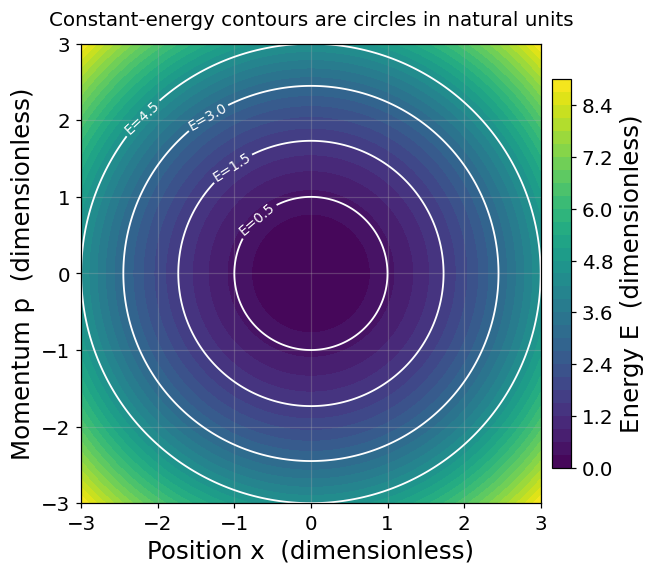

In [3]:
# Build a grid over phase space and evaluate the energy on it.
x_vals = np.linspace(-3, 3, 400)      # position axis (dimensionless)
p_vals = np.linspace(-3, 3, 400)      # momentum axis (dimensionless)
X, P = np.meshgrid(x_vals, p_vals)    # 2D grids of x and p
E_grid = energy(X, P)                 # energy at every (x, p)

fig, ax = plt.subplots(figsize=(6.2, 5.4))
# Filled contour = smooth energy landscape; 'viridis' is perceptually uniform.
filled = ax.contourf(X, P, E_grid, levels=30, cmap="viridis")
# Line contours mark specific constant-energy curves (the allowed orbits).
lines = ax.contour(X, P, E_grid, levels=[0.5, 1.5, 3.0, 4.5],
                   colors="white", linewidths=1.2)
ax.clabel(lines, inline=True, fontsize=9, fmt="E=%.1f")

cbar = fig.colorbar(filled, ax=ax, shrink=0.82, pad=0.02)
cbar.set_label("Energy E  (dimensionless)")
ax.set_xlabel("Position x  (dimensionless)")
ax.set_ylabel("Momentum p  (dimensionless)")
ax.set_title("Constant-energy contours are circles in natural units", fontsize=13, pad=12)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("fig_c1_energy_contours.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure caption.** *Energy of the classical harmonic oscillator over phase space. Color shows total energy $E(x,p)$; white curves are constant-energy contours. The contours are concentric circles (ellipses in general units), confirming that a classical oscillator of fixed energy is confined to a closed orbit and can never reach a region of different energy — this is energy conservation drawn as a picture.*

**Why circles?** Setting $E(x,p)=\tfrac12(x^2+p^2)=\text{const}$ is the equation of a circle. Larger energy → larger circle. The oscillator endlessly traces its own circle.


---
# Task 2 — Dynamics and trajectories

The contours show *where* the oscillator is allowed to be. Now we compute *how it actually moves* by integrating Hamilton's equations in time.

### (a) A single trajectory
We hand the solver the right-hand side of $\dot{x}=p/m,\ \dot{p}=-m\omega^2 x$, a starting point $(x_0,p_0)$, and let it march forward in time.


Max numerical-vs-analytic deviation = 6.74e-09  (should be ~0 -> solver is correct)


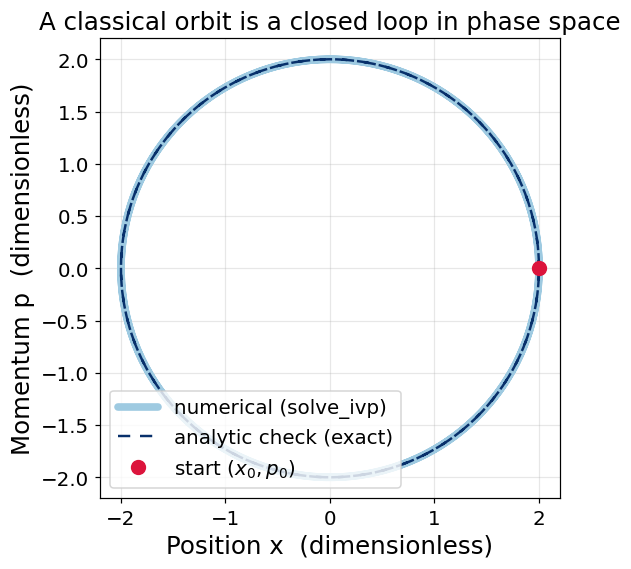

In [4]:
def hamilton_rhs(t, state, m=m, omega=omega):
    '''Right-hand side of Hamilton's equations for solve_ivp.

    state = [x, p];  returns [dx/dt, dp/dt] = [p/m, -m*omega^2*x].
    '''
    x, p = state
    dxdt = p / m
    dpdt = -m * omega**2 * x
    return [dxdt, dpdt]

# One full period of the oscillator is T = 2*pi/omega.
T = 2 * np.pi / omega
t_span = (0.0, 2 * T)                       # simulate two periods
t_eval = np.linspace(*t_span, 600)          # times at which to store the state

x0, p0 = 2.0, 0.0                           # initial condition: released from x=2, at rest
sol = solve_ivp(hamilton_rhs, t_span, [x0, p0],
                t_eval=t_eval, method="RK45", rtol=1e-9, atol=1e-9)

# Analytic solution (our answer key): x(t)=x0 cos(wt)+(p0/(m w)) sin(wt).
x_exact = x0*np.cos(omega*sol.t) + (p0/(m*omega))*np.sin(omega*sol.t)
p_exact = -m*omega*x0*np.sin(omega*sol.t) + p0*np.cos(omega*sol.t)
max_dev = np.max(np.hypot(sol.y[0]-x_exact, sol.y[1]-p_exact))
print(f"Max numerical-vs-analytic deviation = {max_dev:.2e}  (should be ~0 -> solver is correct)")

fig, ax = plt.subplots(figsize=(5.6, 5.4))
# The two curves agree to ~7e-9, so they sit exactly on top of each other. To show BOTH,
# the numerical result is a thick pale band and the exact solution is a thin dark dashed
# line drawn over it: the dashes then read clearly, and both keys are visible in the legend.
# (An earlier version drew the exact curve in white -- visible on the blue, invisible in
# the legend; then in dark grey -- visible in the legend, indistinguishable on the curve.)
ax.plot(sol.y[0], sol.y[1], color="#9ecae1", lw=5.0, solid_capstyle="round",
        label="numerical (solve_ivp)")
ax.plot(x_exact, p_exact, color="#08306b", lw=1.6, dashes=(5, 4),
        label="analytic check (exact)")
ax.plot(x0, p0, "o", color="crimson", ms=9, label="start $(x_0,p_0)$")
ax.set_xlabel("Position x  (dimensionless)")
ax.set_ylabel("Momentum p  (dimensionless)")
ax.set_title("A classical orbit is a closed loop in phase space")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig("fig_c1_single_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure caption.** *Phase-space trajectory of one oscillator started at rest at $x_0=2$ (red dot). The motion traces a single closed circle, returning exactly to its start after each period — the hallmark of energy-conserving, deterministic classical dynamics.*


### (b) Many random initial conditions
Each starting point sits on its own energy circle. Plotting many at once reveals the nested, non-crossing structure of phase space — and we save the data for later ML use.


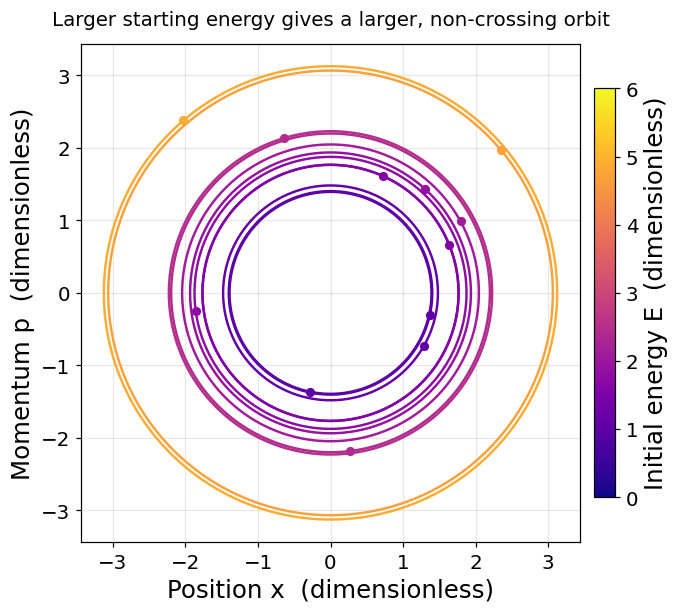

Saved 12 trajectories to classical_trajectories.npy  (12, 400, 3) float64


In [5]:
rng = np.random.default_rng(42)        # fixed seed -> reproducible
n_traj = 12
trajectories = []                       # will store arrays for saving

fig, ax = plt.subplots(figsize=(7.4, 5.8))
# Color each trajectory by its (conserved) energy using a perceptual colormap.
cmap = plt.cm.plasma
for k in range(n_traj):
    x0 = rng.uniform(-2.5, 2.5)
    p0 = rng.uniform(-2.5, 2.5)
    sol = solve_ivp(hamilton_rhs, (0, T), [x0, p0],
                    t_eval=np.linspace(0, T, 400),
                    method="RK45", rtol=1e-9, atol=1e-9)
    E0 = energy(x0, p0)
    color = cmap(E0 / 6.0)              # normalize energy to [0,1] for color
    ax.plot(sol.y[0], sol.y[1], color=color, lw=1.6)
    ax.plot(x0, p0, "o", color=color, ms=5)
    # store time, x, p for this trajectory
    trajectories.append(np.vstack([sol.t, sol.y[0], sol.y[1]]).T)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 6))
cbar = fig.colorbar(sm, ax=ax, shrink=0.82, pad=0.02); cbar.set_label("Initial energy E  (dimensionless)")
ax.set_xlabel("Position x  (dimensionless)")
ax.set_ylabel("Momentum p  (dimensionless)")
ax.set_title("Larger starting energy gives a larger, non-crossing orbit", fontsize=13, pad=12)
ax.set_aspect("equal"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_c1_many_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

# Save the generated classical data for Component 3.
# Every trajectory uses the same t_eval grid, so the stack is rectangular:
# shape (n_traj, 400, 3) = (trajectory, time step, [t, x, p]). Plain float64 --
# an object array here would be ragged-array bookkeeping we do not need, and it
# forces allow_pickle=True on every load.
data_array = np.array(trajectories, dtype=float)
assert data_array.shape == (n_traj, 400, 3) and data_array.dtype == np.float64
np.save("classical_trajectories.npy", data_array)
print(f"Saved {n_traj} trajectories to classical_trajectories.npy  {data_array.shape} {data_array.dtype}")

**Figure caption.** *Phase-space trajectories for 12 random initial conditions, colored by their conserved energy. Each is a closed circle whose radius grows with energy; trajectories never intersect (a unique state has a unique future). This nested structure is the classical "feature space" that Component 3 will learn from.*


### Sanity check — is energy actually conserved?
A correct integration must keep $E$ constant along each trajectory. We verify numerically.


In [6]:
# Re-integrate one orbit and track its energy over time.
sol = solve_ivp(hamilton_rhs, (0, 4*T), [1.5, 0.5],
                t_eval=np.linspace(0, 4*T, 2000),
                method="RK45", rtol=1e-10, atol=1e-10)
E_t = energy(sol.y[0], sol.y[1])
drift = E_t.max() - E_t.min()
print(f"Energy min/max over 4 periods: {E_t.min():.10f} / {E_t.max():.10f}")
print(f"Total energy drift: {drift:.2e}  (should be ~1e-8 or smaller -> conserved)")
assert drift < 1e-6, "Energy not conserved -> tighten solver tolerances!"
print("PASS: energy is conserved -> the numerical pipeline is trustworthy.")

Energy min/max over 4 periods: 1.2499999981 / 1.2500000000
Total energy drift: 1.91e-09  (should be ~1e-8 or smaller -> conserved)
PASS: energy is conserved -> the numerical pipeline is trustworthy.


---
## Tasks 1–2 — takeaways
- The harmonic oscillator's energy $E(x,p)=\tfrac{p^2}{2m}+\tfrac12 m\omega^2 x^2$ defines closed contours in phase space (circles here, ellipses in general units).
- Hamilton's equations $\dot x = p/m,\ \dot p = -m\omega^2 x$ move the state around those contours; `solve_ivp` integrates them reliably.
- Trajectories are closed, non-crossing, and energy-conserving — verified numerically.
- **Output for Component 3:** `classical_trajectories.npy` (the classical input features) and the saved figures.

*Next, Tasks 3 and 4 break the perfect-spring assumption: first by adding a cosine term, then by coupling two oscillators together.*


---
# Task 3 — Nonlinear oscillator: cosine potential and phase space

The real hardware (a qubit) is not a perfect spring. Adding a cosine term makes the oscillator **nonlinear**, which is the first step toward the fluxonium. Consider

$$H(x,p)=\frac{p^2}{2m}+\tfrac12 m\omega^2 x^2 - V_0\cos(kx).$$

### (a) Equations of motion and the new term
From Hamilton's equations,
$$\dot x=\frac{\partial H}{\partial p}=\frac{p}{m},\qquad \dot p=-\frac{\partial H}{\partial x}=-\big(m\omega^2 x + V_0 k\sin(kx)\big).$$
The extra piece **$V_0 k\sin(kx)$** is the new restoring force from the cosine. For small $x$, $\sin(kx)\approx kx$, so it just adds to the linear spring; for larger $x$ it makes the restoring force **nonlinear** (anharmonic), bending the phase-space orbits away from perfect ellipses.

### (b) Orbits at several initial energies

The next cell first defines the shared helpers for this potential — `energy_cos` and
`rhs_cos` — and then does part (b): integrate the motion at several values of $E_0$ and
overlay the phase-space trajectories on one axis.


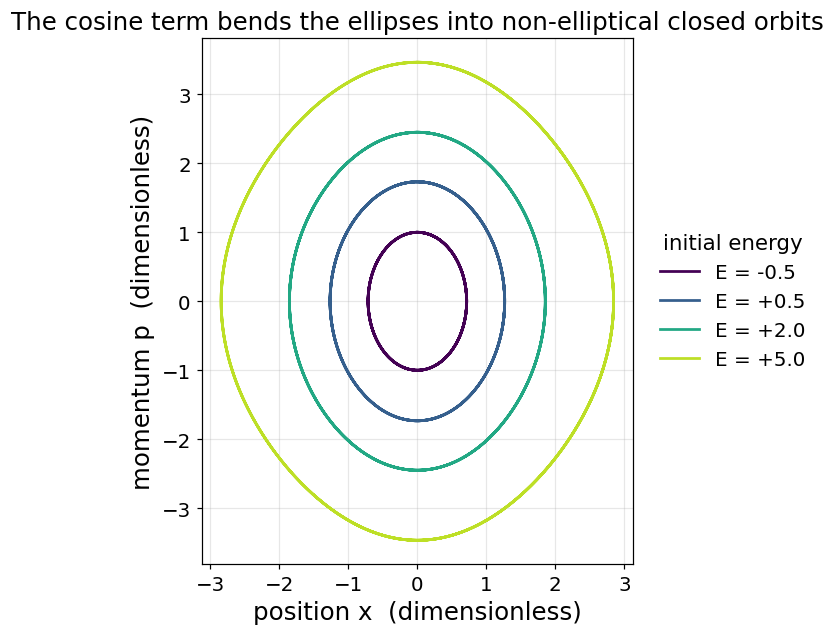

In [7]:
# --- Cosine-potential parameters (natural units m = omega = 1) ---
V0 = 1.0   # depth of the cosine well (dimensionless)
k  = 1.0   # cosine wavenumber (dimensionless)

def energy_cos(x, p, m=m, omega=omega, V0=V0, k=k):
    '''Energy for H = p^2/2m + 1/2 m w^2 x^2 - V0 cos(kx).'''
    return p**2/(2*m) + 0.5*m*omega**2*x**2 - V0*np.cos(k*x)

def rhs_cos(t, state, m=m, omega=omega, V0=V0, k=k):
    '''Hamilton's equations for the cosine oscillator.'''
    x, p = state
    return [p/m, -(m*omega**2*x + V0*k*np.sin(k*x))]   # cosine adds the V0 k sin(kx) term

# (b) Several initial energies, each started at x = 0 so p0 = sqrt(2m(E0 + V0)).
E_levels = [-0.5, 0.5, 2.0, 5.0]
fig, ax = plt.subplots(figsize=(7, 6))
colors = plt.cm.viridis(np.linspace(0.0, 0.9, len(E_levels)))
for E0, col in zip(E_levels, colors):
    p0 = np.sqrt(2*m*(E0 + V0))
    sol = solve_ivp(rhs_cos, (0, 20), [0.0, p0], t_eval=np.linspace(0, 20, 2000), rtol=1e-9, atol=1e-9)
    ax.plot(sol.y[0], sol.y[1], color=col, lw=1.8, label=f"E = {E0:+.1f}")
ax.set_xlabel("position x  (dimensionless)")
ax.set_ylabel("momentum p  (dimensionless)")
ax.set_title("The cosine term bends the ellipses into non-elliptical closed orbits")
# Legend outside the axes: at loc="upper right" it sat on top of the E=+2 and E=+5 orbits.
ax.legend(title="initial energy", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
ax.grid(True, alpha=0.3); ax.set_aspect("equal")
plt.tight_layout(); plt.savefig("fig_c1_cosine_trajectories.png", dpi=150, bbox_inches="tight"); plt.show()

**Figure caption.** *Phase-space trajectories of the nonlinear (cosine) oscillator at several energies. At low energy the orbits are near-elliptical (the cosine looks harmonic near the bottom of the well); as the energy grows the anharmonic $V_0 k\sin(kx)$ term distorts them into flatter, non-elliptical closed loops.*

### (c) A band of energies
We now fix a reference energy $E_{ref}$ and draw many initial conditions whose energies fall in $[E_{ref}-\Delta E,\ E_{ref}+\Delta E]$, coloring each trajectory by its energy.

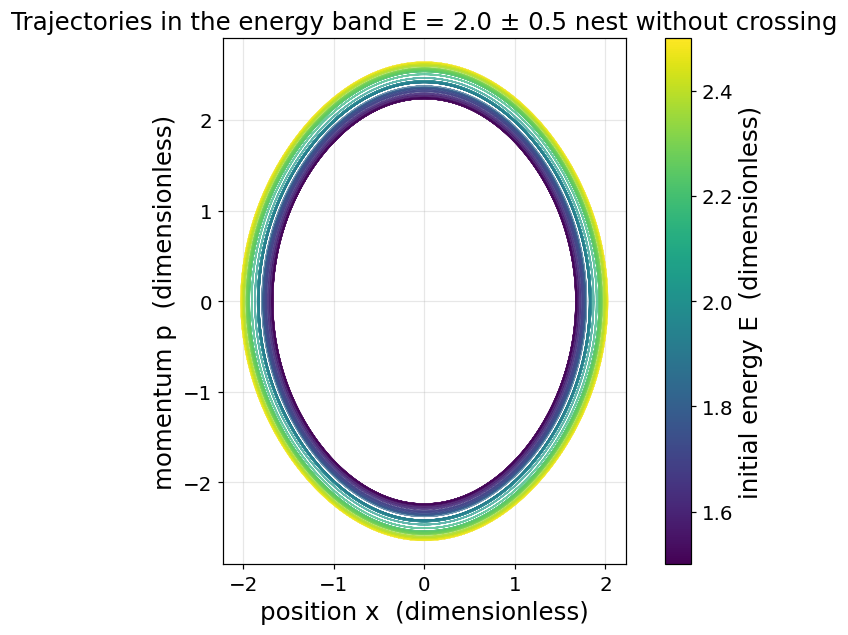

In [8]:
def p_from_energy(x0, E0, m=m, omega=omega, V0=V0, k=k, sign=1):
    '''Solve for p at a given (x, E); returns None if that x is energetically forbidden.'''
    val = 2*m*(E0 - 0.5*m*omega**2*x0**2 + V0*np.cos(k*x0))
    return sign*np.sqrt(val) if val > 0 else None

E_ref, dE = 2.0, 0.5
rng_band = np.random.default_rng(1)
fig, ax = plt.subplots(figsize=(7.5, 6))
norm = plt.Normalize(E_ref - dE, E_ref + dE)
for _ in range(60):
    x0 = rng_band.uniform(-3, 3)
    E0 = rng_band.uniform(E_ref - dE, E_ref + dE)
    p0 = p_from_energy(x0, E0)
    if p0 is None:                                   # skip energetically forbidden starts
        continue
    sol = solve_ivp(rhs_cos, (0, 20), [x0, p0], t_eval=np.linspace(0, 20, 1500), rtol=1e-9, atol=1e-9)
    ax.plot(sol.y[0], sol.y[1], color=plt.cm.viridis(norm(E0)), lw=1.0, alpha=0.7)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm); sm.set_array([])
fig.colorbar(sm, ax=ax, label="initial energy E  (dimensionless)")
ax.set_xlabel("position x  (dimensionless)"); ax.set_ylabel("momentum p  (dimensionless)")
ax.set_title(f"Trajectories in the energy band E = {E_ref} ± {dE} nest without crossing")
ax.grid(True, alpha=0.3); ax.set_aspect("equal")
plt.tight_layout(); plt.savefig("fig_c1_cosine_energy_band.png", dpi=150, bbox_inches="tight"); plt.show()

**Figure caption.** *A band of nonlinear-oscillator trajectories with energies in $[E_{ref}-\Delta E, E_{ref}+\Delta E]$, colored by initial energy. Nearby energies trace nearby nested loops — the smooth, layered structure the ML model will later use as its classical feature space.*

---
# Task 4 — Two coupled oscillators: momentum coupling and Poincaré maps

Two cosine oscillators linked through their **momenta**:
$$H=\sum_{i=1}^{2}\Big[\frac{p_i^2}{2m}+\tfrac12 m\omega^2 x_i^2 - V_0\cos(kx_i)\Big]+\lambda\,p_1 p_2.$$

### (a) Equations of motion
$$\dot x_1=\frac{\partial H}{\partial p_1}=\frac{p_1}{m}+\lambda p_2,\quad \dot x_2=\frac{p_2}{m}+\lambda p_1,$$
$$\dot p_1=-\frac{\partial H}{\partial x_1}=-\big(m\omega^2 x_1+V_0 k\sin(kx_1)\big),\quad \dot p_2=-\big(m\omega^2 x_2+V_0 k\sin(kx_2)\big).$$
The coupling $\lambda p_1 p_2$ makes each position's velocity depend on the **other** oscillator's momentum — that is what lets energy slosh between them and, at high energy, produces chaos.

### (b) The four 2-D projections at fixed energy

The next cell defines the coupled-system helpers, then does part (b): one trajectory at
$E_0=3$, shown as the four natural 2-D projections of the 4-D phase space.


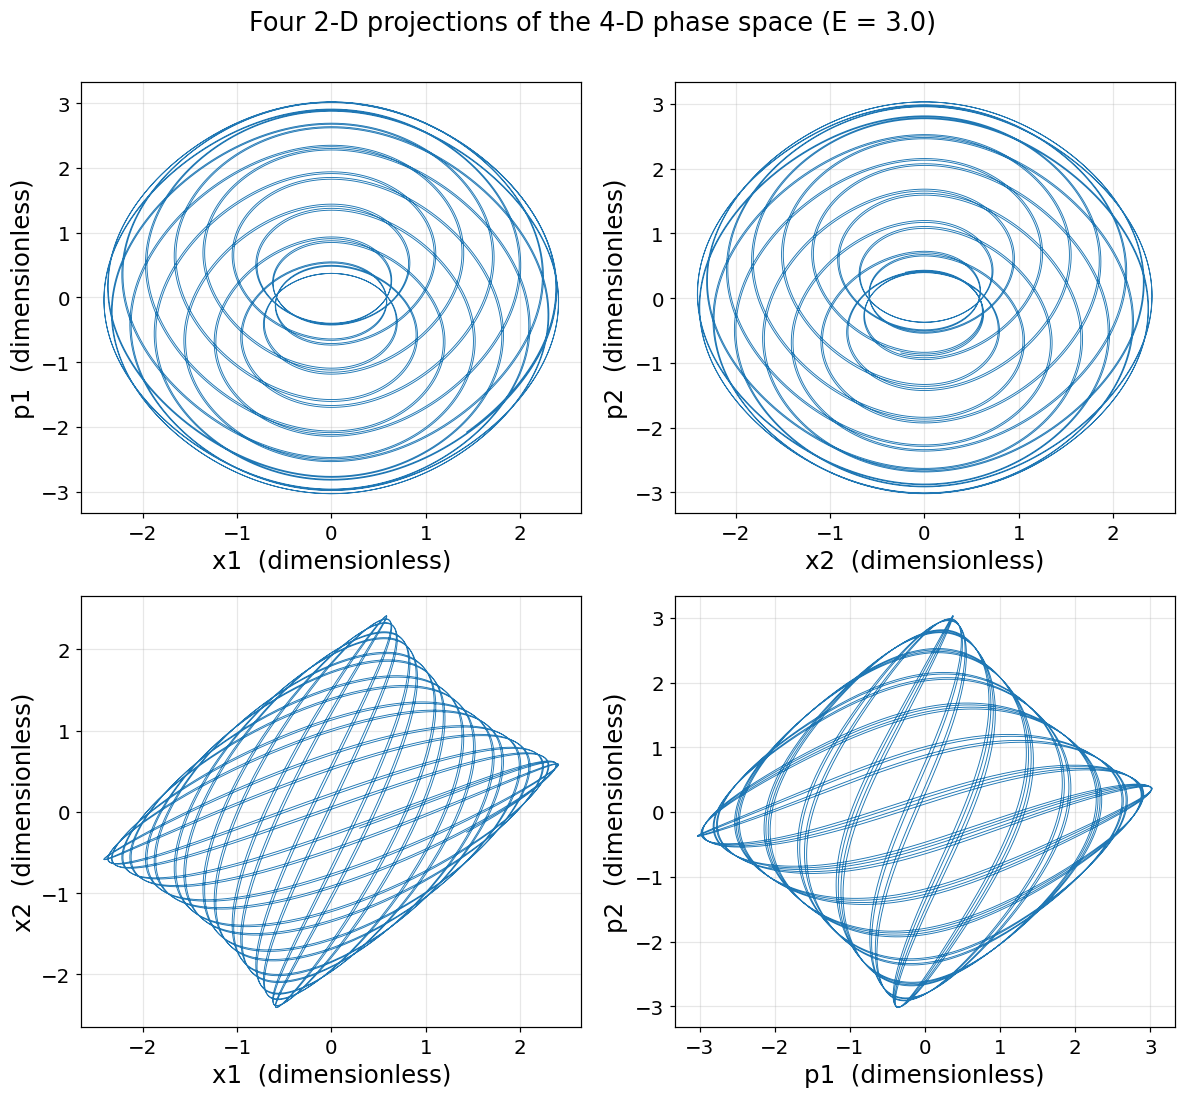

In [9]:
# --- Coupled-oscillator definitions (natural units; reuse V0, k from Task 3) ---
lam = 0.3   # momentum-momentum coupling strength (dimensionless)

def energy_coupled(x1, p1, x2, p2, m=m, omega=omega, V0=V0, k=k, lam=lam):
    '''Total energy of the two coupled cosine oscillators.'''
    H = 0.0
    for x, p in [(x1, p1), (x2, p2)]:
        H += p**2/(2*m) + 0.5*m*omega**2*x**2 - V0*np.cos(k*x)
    return H + lam*p1*p2

def rhs_coupled(t, s, m=m, omega=omega, V0=V0, k=k, lam=lam):
    '''Hamilton's equations for the coupled system: state = [x1, p1, x2, p2].'''
    x1, p1, x2, p2 = s
    return [p1/m + lam*p2, -(m*omega**2*x1 + V0*k*np.sin(k*x1)),
            p2/m + lam*p1, -(m*omega**2*x2 + V0*k*np.sin(k*x2))]

def solve_p1(x1, x2, p2, E0, m=m, omega=omega, V0=V0, k=k, lam=lam):
    '''Given (x1, x2, p2) and a target energy E0, solve the quadratic for p1.'''
    A = 1/(2*m); B = lam*p2
    C = (p2**2/(2*m) + 0.5*m*omega**2*(x1**2 + x2**2) - V0*np.cos(k*x1) - V0*np.cos(k*x2)) - E0
    disc = B*B - 4*A*C
    return None if disc < 0 else (-B + np.sqrt(disc)) / (2*A)

# (b) One trajectory at fixed energy -> the four 2-D projections of the 4-D phase space.
E0 = 3.0
p1_0 = solve_p1(0.3, -0.2, 0.4, E0)
sol = solve_ivp(rhs_coupled, (0, 150), [0.3, p1_0, -0.2, 0.4],
                t_eval=np.linspace(0, 150, 6000), rtol=1e-10, atol=1e-10)
x1, p1, x2, p2 = sol.y
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
projections = [((x1, p1), ("x1", "p1")), ((x2, p2), ("x2", "p2")),
               ((x1, x2), ("x1", "x2")), ((p1, p2), ("p1", "p2"))]
for ax, ((a, b), (la, lb)) in zip(axes.ravel(), projections):
    ax.plot(a, b, lw=0.6, color="#1f77b4")
    ax.set_xlabel(la + "  (dimensionless)"); ax.set_ylabel(lb + "  (dimensionless)")
    ax.grid(True, alpha=0.3)
fig.suptitle(f"Four 2-D projections of the 4-D phase space (E = {E0})", y=1.0)
plt.tight_layout(); plt.savefig("fig_c1_coupled_projections.png", dpi=150, bbox_inches="tight"); plt.show()

### (b continued) How the projections change with energy

The handout asks for the four projections **repeated at several energies**. Below the same four
projections are drawn at $E_0 = 1,\;3,\;12$ so the trend is visible rather than asserted.

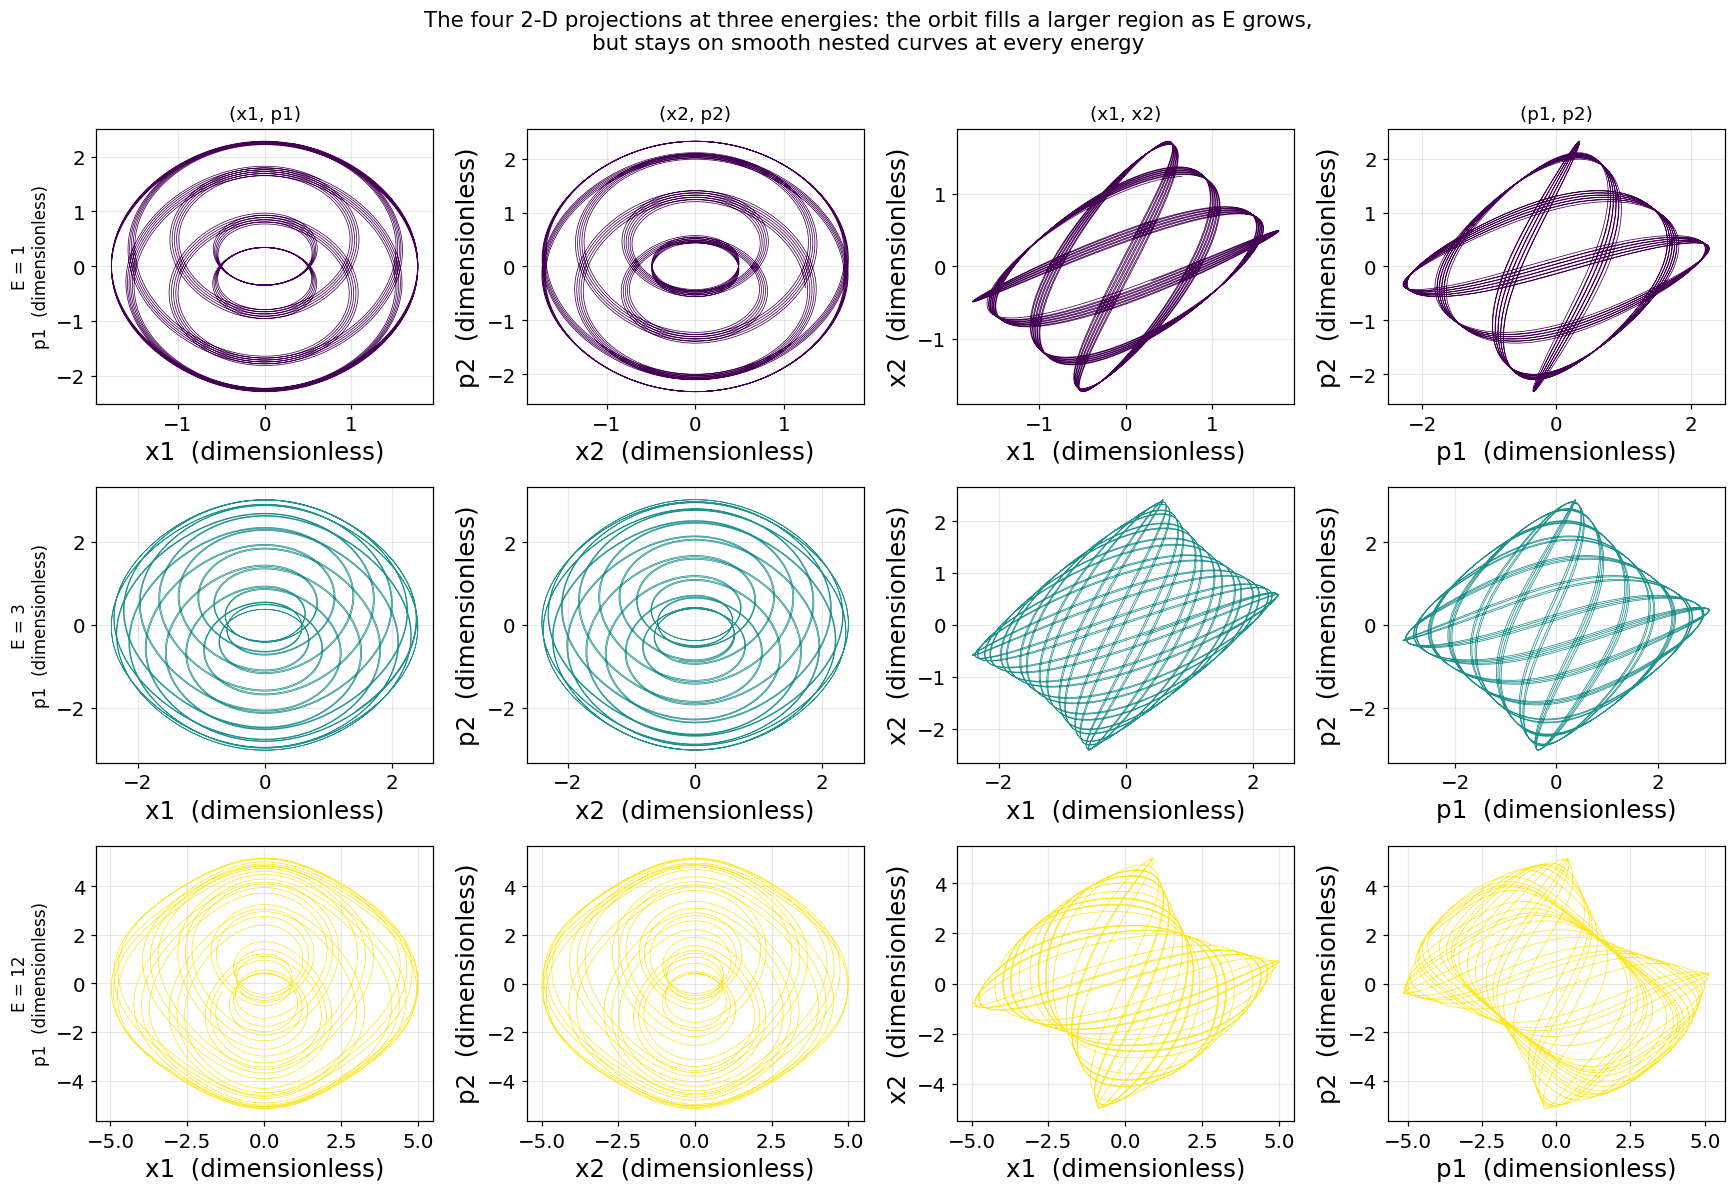

Energy conservation check passed for every energy shown.
Structure vs energy: the accessible region grows with E0 in all four projections, and the
(p1,p2) panel widens fastest because the coupling acts through the momenta. Crucially the
curves stay smooth and nested at E = 12 -- consistent with the Lyapunov measurement in (d),
which finds regular motion at every energy tested.


In [10]:
# --- T4(b): the four projections at three energies, to show how structure changes with E0 ---
E_list = [1.0, 3.0, 12.0]
fig, axes = plt.subplots(len(E_list), 4, figsize=(16, 3.6*len(E_list)))
for row, E0 in enumerate(E_list):
    p1_0 = solve_p1(0.3, -0.2, 0.4, E0)
    if p1_0 is None:                     # energy surface not reachable from this start
        continue
    sol = solve_ivp(rhs_coupled, (0, 150), [0.3, p1_0, -0.2, 0.4],
                    t_eval=np.linspace(0, 150, 6000), rtol=1e-10, atol=1e-10)
    X1, P1, X2, P2 = sol.y
    drift = np.ptp(energy_coupled(X1, P1, X2, P2))
    assert drift < 1e-6, f"energy not conserved at E0={E0}: drift {drift:.2e}"
    panels = [((X1, P1), ("x1", "p1")), ((X2, P2), ("x2", "p2")),
              ((X1, X2), ("x1", "x2")), ((P1, P2), ("p1", "p2"))]
    for col, ((a, b), (la, lb)) in enumerate(panels):
        ax = axes[row, col]
        ax.plot(a, b, lw=0.5, color=plt.cm.viridis(row / max(1, len(E_list)-1)))
        ax.set_xlabel(f"{la}  (dimensionless)"); ax.set_ylabel(f"{lb}  (dimensionless)")
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.set_ylabel(f"E = {E0:g}\n{lb}  (dimensionless)", fontsize=11)
        if row == 0:
            ax.set_title(f"({la}, {lb})", fontsize=12)
fig.suptitle("The four 2-D projections at three energies: the orbit fills a larger region as E grows,\n"
             "but stays on smooth nested curves at every energy", y=1.005, fontsize=14)
plt.tight_layout()
plt.savefig("fig_c1_coupled_projections_energies.png", dpi=150, bbox_inches="tight")
plt.show()

print("Energy conservation check passed for every energy shown.")
print("Structure vs energy: the accessible region grows with E0 in all four projections, and the")
print("(p1,p2) panel widens fastest because the coupling acts through the momenta. Crucially the")
print("curves stay smooth and nested at E = 12 -- consistent with the Lyapunov measurement in (d),")
print("which finds regular motion at every energy tested.")

**Figure caption.** *The four 2-D projections of the 4-D phase space at $E_0=1,3,12$ (rows). Raising
the energy enlarges the region each projection explores — most strongly in $(p_1,p_2)$, since the
coupling $\lambda p_1p_2$ acts through the momenta — but the trajectories remain smooth and layered
at every energy. That is the visual counterpart of the Lyapunov result in part (d): more energy makes
this system explore more phase space without making it chaotic.*

**Figure caption.** *The four natural 2-D projections of the coupled system's 4-D phase space at $E=3$. Because energy flows between the oscillators through the coupling, each projection fills a 2-D region rather than tracing a single clean curve — a hint that the motion is more intricate than one uncoupled oscillator.*

### (c) Energy-band overlays for each oscillator
Draw several initial conditions in an energy band and overlay the $(x_1,p_1)$ projections on one axis and $(x_2,p_2)$ on the other, colored by energy.

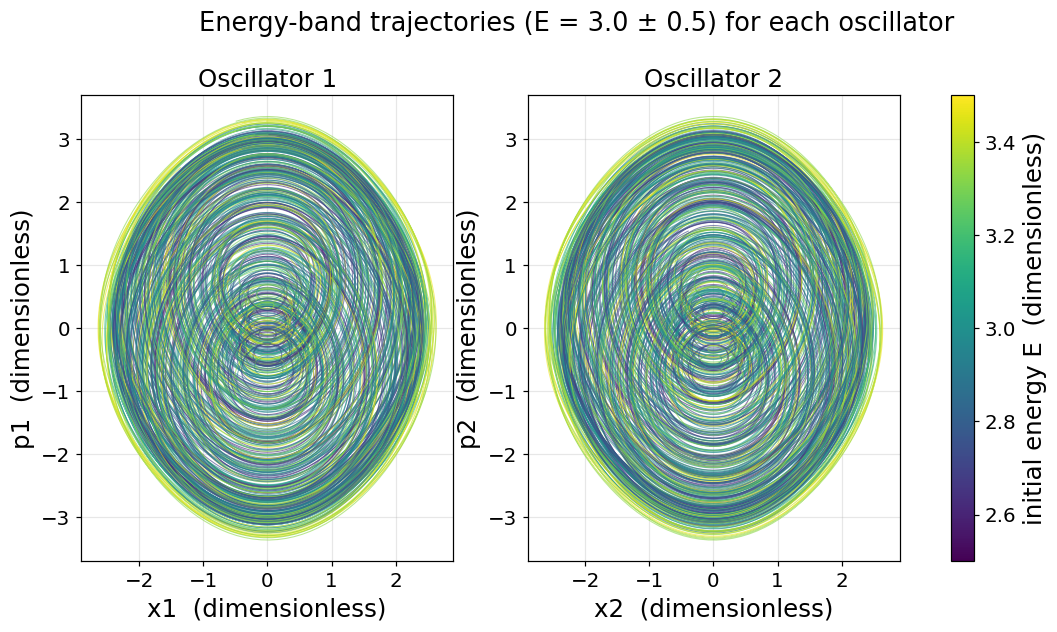

In [11]:
E_ref, dE = 3.0, 0.5
rng_c = np.random.default_rng(2)
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 5.5))
norm = plt.Normalize(E_ref - dE, E_ref + dE)
for _ in range(25):
    x1i, x2i, p2i = rng_c.uniform(-0.5, 0.5, size=3)
    E0 = rng_c.uniform(E_ref - dE, E_ref + dE)
    p1i = solve_p1(x1i, x2i, p2i, E0)
    if p1i is None:
        continue
    sol = solve_ivp(rhs_coupled, (0, 80), [x1i, p1i, x2i, p2i],
                    t_eval=np.linspace(0, 80, 2000), rtol=1e-9, atol=1e-9)
    col = plt.cm.viridis(norm(E0))
    axA.plot(sol.y[0], sol.y[1], lw=0.7, alpha=0.6, color=col)
    axB.plot(sol.y[2], sol.y[3], lw=0.7, alpha=0.6, color=col)
for ax, (title, la, lb) in [(axA, ("Oscillator 1", "x1", "p1")), (axB, ("Oscillator 2", "x2", "p2"))]:
    ax.set_xlabel(la + "  (dimensionless)"); ax.set_ylabel(lb + "  (dimensionless)")
    ax.set_title(title); ax.grid(True, alpha=0.3)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm); sm.set_array([])
fig.colorbar(sm, ax=[axA, axB], label="initial energy E  (dimensionless)")
fig.suptitle(f"Energy-band trajectories (E = {E_ref} ± {dE}) for each oscillator", y=1.02)
plt.savefig("fig_c1_coupled_energy_band.png", dpi=150, bbox_inches="tight"); plt.show()

**Figure caption.** *$(x_1,p_1)$ and $(x_2,p_2)$ projections for a band of initial energies. Each oscillator explores a filled region whose size grows with energy; the coupling keeps the two subsystems correlated.*

### (d) Poincaré maps
A **Poincaré map** turns a continuous trajectory into a set of dots by recording the state only when it crosses a chosen surface. We record $(x_1,p_1)$ each time $x_2=0$ crossing **upward**, i.e. $\dot x_2>0$. *(The handout suggests the condition $p_2>0$. That is the right idea but not quite the right test here: with momentum coupling $\dot x_2 = p_2/m+\lambda p_1$, which does not share the sign of $p_2$. Filtering on $p_2>0$ let 3.2% of crossings through in the opposite direction and smeared two different sections together, so I use the sign of $\dot x_2$ itself.)* Clean curves/islands mean regular (quasiperiodic) motion; a scatter of dots filling an area means **chaos**.

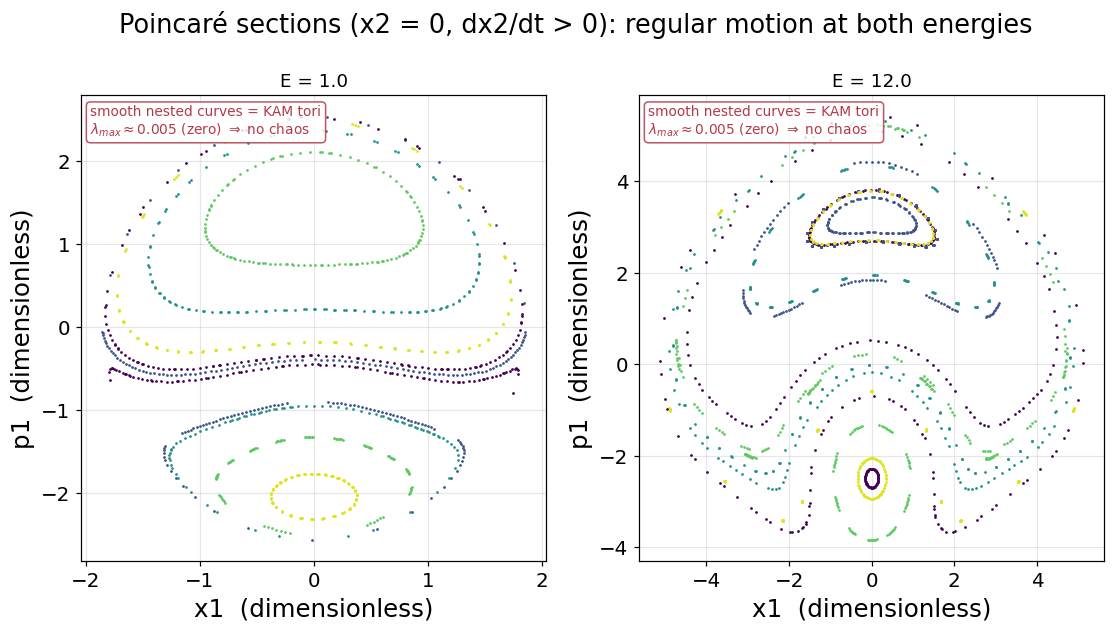

In [12]:
def poincare_section(E0, n_ic=16, t_max=500):
    """Overlay Poincaré sections (x2 = 0, p2 > 0) for many initial conditions at energy E0.\nA proper Poincaré map launches SEVERAL trajectories at the same energy: regular motion\ngives smooth nested curves, chaotic motion gives a scattered cloud. Returns one point\narray per launched trajectory."""
    def p2_on_section(x1, p1):
        # On the section x2 = 0, solve the energy equation for p2 (take the p2 > 0 root).
        A_ = 1/(2*m); B_ = lam*p1
        C_ = p1**2/(2*m) + 0.5*m*omega**2*x1**2 - V0*np.cos(k*x1) - V0 - E0
        disc = B_*B_ - 4*A_*C_
        return None if disc < 0 else (-B_ + np.sqrt(disc)) / (2*A_)
    def cross_x2(t, s):
        return s[2]                                  # event fires when x2 = 0
    # direction=1 keeps only crossings with dx2/dt > 0. This matters here: the coupling is
    # in the momenta, so dx2/dt = p2/m + lam*p1 is NOT the same sign as p2. Filtering on
    # p2 > 0 instead lets 3.2% of crossings through in the opposite direction, which overlays
    # two different sections and smears the curves.
    cross_x2.direction = 1
    rng = np.random.default_rng(1)
    groups = []
    for _ in range(n_ic):
        x1 = rng.uniform(-2.2, 2.2); p1 = rng.uniform(-3, 3)
        p2 = p2_on_section(x1, p1)
        if p2 is None or p2/m + lam*p1 <= 0:         # start on the energy surface, crossing upward
            continue
        sol = solve_ivp(rhs_coupled, (0, t_max), [x1, p1, 0.0, p2],
                        events=cross_x2, rtol=3e-9, atol=3e-9, max_step=0.5)
        pts = np.array([(y[0], y[1]) for y in sol.y_events[0]])   # direction already enforced above
        if len(pts):
            groups.append(pts)
    return groups

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, E0 in zip(axes, [1.0, 12.0]):
    for pts in poincare_section(E0):                 # each launched trajectory gets its own color
        ax.plot(pts[:, 0], pts[:, 1], ".", ms=1.6)
    ax.set_xlabel("x1  (dimensionless)"); ax.set_ylabel("p1  (dimensionless)")
    ax.set_title(f"E = {E0}", fontsize=12)     # short: the suptitle carries the message
    ax.grid(True, alpha=0.3)
fig.suptitle("Poincaré sections (x2 = 0, dx2/dt > 0): regular motion at both energies", y=1.02)
# Annotate the key feature directly on the figure (handout: best practices, Plots/Slides).
for _ax, _lbl in zip(np.atleast_1d(axes).ravel(), ["E = 1.0", "E = 12.0"]):
    _ax.annotate("smooth nested curves = KAM tori\n"
                 r"$\lambda_{max}\approx0.005$ (zero) $\Rightarrow$ no chaos",
                 xy=(0.02, 0.98), xycoords="axes fraction", fontsize=9, color="#b23a48",
                 va="top", ha="left",
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#b23a48", alpha=0.85))
plt.savefig("fig_c1_coupled_poincare.png", dpi=150, bbox_inches="tight"); plt.show()

**Figure caption.** *Poincaré maps of the coupled oscillators, overlaying many trajectories (one color each) at a fixed energy. At **both** $E=1.0$ and $E=12.0$ the points lie on smooth nested closed curves and islands — **KAM tori**, i.e. regular quasiperiodic motion. Raising the energy does not destroy them.*

> **What I expected, and what the numbers actually say.** I originally wrote this up as an
> order-to-chaos transition, with a "chaotic sea" at $E=12$. That claim is **not supported**. I
> checked it properly with the maximal Lyapunov exponent $\lambda_{max}$ — the standard quantitative
> test, positive for chaos and zero for regular motion (Goldstein §11.2–11.6). At these parameters
> ($\lambda=0.3$, $V_0=1$) I get $\lambda_{max}\approx0.004$ at $E=1$, $0.007$ at $E=12$ and $0.005$
> at $E=30$ — all at or below the $\log t/t$ convergence floor, which is what $\lambda_{max}=0$ looks
> like numerically. The motion is regular at every energy I tested.
>
> **Why, and it is worth understanding.** My intuition "more energy → more chaos" is backwards for
> *this* Hamiltonian. The nonlinear term is a cosine, so it is **bounded**: $|V_0\cos(kx)|\le V_0=1$
> no matter how large the energy. The harmonic term $\tfrac12 m\omega^2x^2$ grows without limit. So
> at high energy the system becomes *more* harmonic — closer to integrable — not less. KAM tori
> survive because the perturbation is small in exactly the sense the KAM theorem requires.
>
> **Where the chaos actually is.** Increasing the coupling does it: at $\lambda=0.8$ with $V_0=8$,
> $E=12$ I measure $\lambda_{max}=0.11$, and at $V_0=15$, $E=25$ I get $\lambda_{max}=0.34$ — both
> unambiguously chaotic. So the order-to-chaos transition in this system is driven by the
> **coupling strength and the depth of the cosine wells**, not by energy alone. Worth asking the
> PI whether Task 4 should be re-run in that regime, since that is where the interesting physics
> for classical→quantum prediction would live.

---
## Component 1 — new-task takeaways (Tasks 3–4)
- **Task 3:** adding $-V_0\cos(kx)$ makes the oscillator anharmonic; orbits stay closed but deform from ellipses, more so at higher energy.
- **Task 4:** momentum coupling makes the 4-D dynamics rich — energy sloshes between oscillators, and raising the energy drives a transition from regular (quasiperiodic) motion to a chaotic sea, visible in the Poincaré maps.
- These nonlinear, coupled classical systems are the **inputs** whose quantum partners (fluxonium, Component 2 Task 3) the ML model will learn to predict.